# OCTO Mobile Review - Bag of Words (BoW) Analysis

**Nama:** Alisha Rafimalia

**NRP:** 5026231202

**Kelas:** PBA A

**Notebook:** 2 - BoW Analysis

Notebook ini mengikuti alur BoW dari materi perkuliahan dan menerapkannya pada data review OCTO Mobile.

Tujuan:
1. Melakukan preprocessing teks (tokenize, stopword removal, stemming).
2. Menampilkan kata unik.
3. Membuat mapping kata berdasarkan frekuensi.
4. Membentuk matriks BoW dengan CountVectorizer.
5. Menganalisis kata dominan secara umum dan per sentimen.

In [5]:
!pip -q install nltk Sastrawi scikit-learn seaborn matplotlib pandas

### Penjelasan Output
- Sel ini menginstal dependensi utama untuk preprocessing bahasa, BoW, dan visualisasi.
- Jika instalasi selesai tanpa error, semua library siap dipakai pada langkah berikutnya.

In [6]:
import re
from collections import Counter

import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Penjelasan Output
- Pesan `Libraries loaded successfully.` menandakan import berhasil.
- Jika muncul warning minor dari NLTK download, biasanya masih aman selama resource utama tersedia.

In [7]:
from pathlib import Path

# Load data hasil scraping bersih dari beberapa kemungkinan lokasi file
candidate_paths = [
    "../WEEK 2/hasil_scraping_octo_clean.csv",
    "WEEK 2/hasil_scraping_octo_clean.csv",
    "../.qodo/WEEK 2/hasil_scraping_octo_clean.csv",
    "./.qodo/WEEK 2/hasil_scraping_octo_clean.csv",
    ".qodo/WEEK 2/hasil_scraping_octo_clean.csv",
    "hasil_scraping_octo_clean.csv",
]

df = None
used_path = None

for path in candidate_paths:
    try:
        df = pd.read_csv(path)
        used_path = path
        break
    except FileNotFoundError:
        continue

# Fallback: cari file secara rekursif dari current dir
if df is None:
    matches = list(Path.cwd().rglob("hasil_scraping_octo_clean.csv"))
    if matches:
        used_path = str(matches[0])
        df = pd.read_csv(used_path)

if df is None:
    raise FileNotFoundError(
        "File hasil_scraping_octo_clean.csv tidak ditemukan. Pastikan file ada di folder WEEK 2."
    )

print(f"Data loaded from: {used_path}")
print("Shape:", df.shape)
df.head()

Data loaded from: ../WEEK 2/hasil_scraping_octo_clean.csv
Shape: (5000, 11)


,reviewId,userName,score,content,at,thumbsUpCount,replyContent,repliedAt,review_length,month,sentimen_label
0,b5e135fc-94c4-4a35-bbfc-f8cc3a977367,erli shop,5,faforit banget. user friendly,2026-04-05 13:11:16,0,Terima kasih atas bintang lima dan review nya....,2026-04-05 13:15:19,29,2026-04,positif
1,61ea84b8-43b2-4883-ac0f-d55c99319646,Muhamad Rizki,3,aneh aplikasi sudah versi terbaru tapi tetep G...,2026-04-05 12:54:35,0,Mohon maaf atas ketidaknyamanan yang dialami. ...,2026-04-05 13:15:22,151,2026-04,netral
2,b81ce971-d1d9-4280-958f-39a79847ddb5,tia lestari dewi,5,give good transaction experience,2026-04-05 12:46:55,0,Thank you very much for the compliment! Keep u...,2026-04-05 13:14:55,32,2026-04,positif
3,88a4987c-ef87-4246-a5dc-d5be07fd2eb3,Rony Rihard,5,"CIMB memang virtual account ter ""the best"", cu...",2026-04-05 11:38:12,0,Terima kasih atas supportnya. Aplikasi OCTO se...,2026-04-05 11:45:41,153,2026-04,positif
4,b5298f85-2875-4668-a32d-2f2f4db451b4,Awaluddin M,5,mantap gratis admin,2026-04-05 10:21:01,0,Terima kasih atas bintang lima dan review nya....,2026-04-05 10:45:43,19,2026-04,positif


### Penjelasan Output
- Output `Data loaded from` menunjukkan lokasi file CSV yang berhasil dibaca.
- `Shape` menunjukkan jumlah baris dan kolom data input untuk analisis BoW.
- Tabel `head()` digunakan untuk validasi cepat apakah kolom `content` siap diproses.

## Step 1: Tokenize data, remove stopwords, dan stemming

Tahap preprocessing untuk membentuk corpus yang siap dipakai di BoW.

In [8]:
# Persiapan komponen preprocessing
stemmer = StemmerFactory().create_stemmer()
stop_words_id = set(stopwords.words("indonesian"))
stop_words_en = set(stopwords.words("english"))
stop_words = stop_words_id.union(stop_words_en)

custom_stopwords = {
    "nya", "yg", "aja", "udah", "ga", "gak", "ok", "apk", "app", "octo", "cimb", "niaga"
}
stop_words = stop_words.union(custom_stopwords)

def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

df_bow = df.copy()
df_bow = df_bow[df_bow["content"].notna()].copy()
df_bow["clean_text"] = df_bow["content"].apply(preprocess_text)
df_bow = df_bow[df_bow["clean_text"].str.len() > 0].copy()

corpus = df_bow["clean_text"].tolist()

print("Jumlah dokumen setelah preprocessing:", len(corpus))
print("Contoh corpus:")
for i in range(min(3, len(corpus))):
    print(f"- {corpus[i]}")

Jumlah dokumen setelah preprocessing: 4742
Contoh corpus:
- faforit banget user friendly
- aneh aplikasi versi baru tetep login pemberitahuan hasil klik coba ulang verifikasi ponsel
- give good transaction experience


### Penjelasan Output
- `Jumlah dokumen setelah preprocessing` menunjukkan banyak review yang lolos tahap cleaning.
- `Contoh corpus` memperlihatkan hasil akhir preprocessing (huruf kecil, tanpa tanda baca, stopword berkurang, dan stemming).
- Jika corpus kosong, berarti filter terlalu ketat atau kolom teks belum terbaca dengan benar.

## Step 2: List all unique words

Mengambil semua kata unik dari corpus hasil preprocessing.

In [9]:
# Finding unique words
all_words = []
for sentence in corpus:
    for word in sentence.split():
        all_words.append(word)

unique_words = sorted(list(set(all_words)))
print("Jumlah unique words:", len(unique_words))
print("Sample unique words (30 pertama):")
print(unique_words[:30])

Jumlah unique words: 3189
Sample unique words (30 pertama):
['aamiin', 'abadi', 'abai', 'abal', 'abis', 'abu', 'acak', 'acc', 'acces', 'accessible', 'account', 'aceh', 'acount', 'ada', 'adaaa', 'adahal', 'adakalanya', 'adakan', 'adeh', 'adim', 'adm', 'admin', 'admindnya', 'administrasi', 'adminnya', 'adminnyaa', 'admint', 'adminya', 'adohhh', 'adu']


### Penjelasan Output
- `Jumlah unique words` menunjukkan ukuran kosakata unik setelah preprocessing.
- Sampel kata membantu mengecek apakah token yang muncul sudah relevan dengan konteks review aplikasi.

## Step 3: Mapping kata ke angka berdasarkan frekuensi (descending)

Membentuk dictionary kata -> indeks berdasarkan frekuensi kemunculan.

In [10]:
word_frequencies = Counter(all_words)
sorted_words = sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)

word_to_number = {}
for i, (word, frequency) in enumerate(sorted_words):
    word_to_number[word] = i + 1

print("Top 20 word frequencies:")
print(sorted_words[:20])

print("Top 20 word-to-number mapping:")
print(dict(list(word_to_number.items())[:20]))

Top 20 word frequencies:
[('mudah', 740), ('aplikasi', 604), ('bagus', 459), ('mantap', 454), ('transaksi', 430), ('bantu', 337), ('cepat', 327), ('bank', 285), ('login', 247), ('buka', 222), ('banget', 214), ('good', 190), ('mobile', 189), ('transfer', 163), ('baik', 162), ('masuk', 160), ('tolong', 151), ('ribet', 150), ('saldo', 138), ('rekening', 133)]
Top 20 word-to-number mapping:
{'mudah': 1, 'aplikasi': 2, 'bagus': 3, 'mantap': 4, 'transaksi': 5, 'bantu': 6, 'cepat': 7, 'bank': 8, 'login': 9, 'buka': 10, 'banget': 11, 'good': 12, 'mobile': 13, 'transfer': 14, 'baik': 15, 'masuk': 16, 'tolong': 17, 'ribet': 18, 'saldo': 19, 'rekening': 20}


### Penjelasan Output
- `Top 20 word frequencies` menunjukkan kata yang paling sering muncul pada seluruh corpus.
- Mapping kata ke nomor merepresentasikan indeks fitur berdasarkan urutan frekuensi.
- Daftar ini penting untuk memahami fitur dominan sebelum modeling.

## Step 4: Bentuk BoW Matrix menggunakan CountVectorizer

Mengubah corpus menjadi representasi numerik Bag of Words.

In [11]:
cv = CountVectorizer(max_features=1000)
X = cv.fit_transform(corpus).toarray()

feature_names = cv.get_feature_names_out()
bow_df = pd.DataFrame(X, columns=feature_names)

print("BoW matrix shape:", bow_df.shape)
print("Jumlah fitur kata:", len(feature_names))
bow_df.head()

BoW matrix shape: (4742, 1000)
Jumlah fitur kata: 1000


,aamiin,abal,abis,acc,account,ada,adakan,adm,admin,administrasi,...,work,worth,woy,xiaomi,xtra,yaa,yah,yng,yuk,zaman
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


### Penjelasan Output
- `BoW matrix shape` menunjukkan ukuran matriks fitur: jumlah dokumen x jumlah kata fitur.
- `Jumlah fitur kata` menunjukkan berapa kata yang dipilih sebagai representasi numerik.
- Tabel `head()` menampilkan sebagian matriks BoW yang siap dipakai untuk klasifikasi/regresi.

## Step 5: Top kata paling sering muncul

Visualisasi frekuensi kata untuk insight cepat terhadap tema review dominan.

/var/folders/jy/25s3m3b54pgdyx0v91ylfww40000gn/T/ipykernel_57820/1176841878.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_df, x="frequency", y="word", palette="viridis")


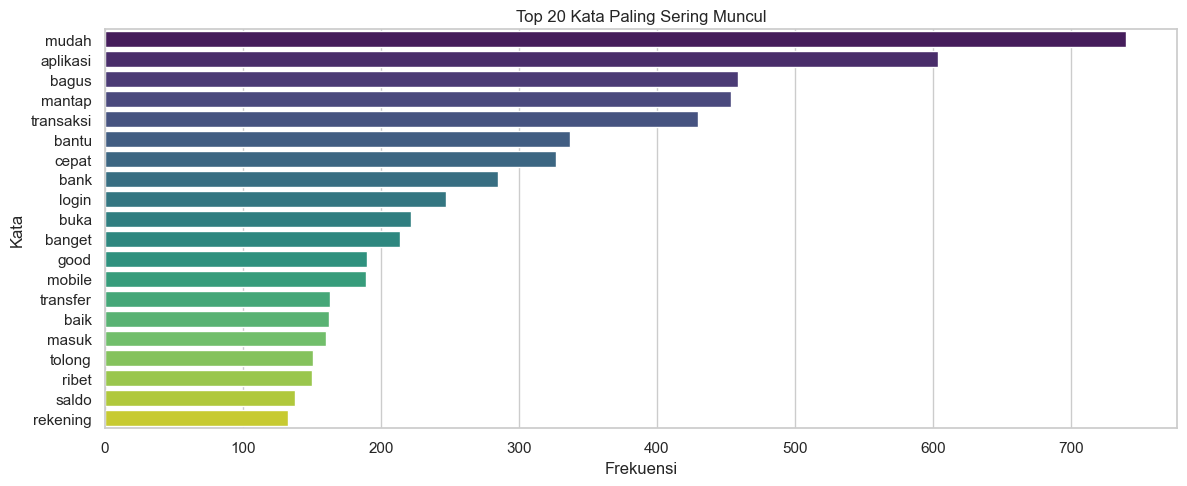

,word,frequency
0,mudah,740
1,aplikasi,604
2,bagus,459
3,mantap,454
4,transaksi,430
5,bantu,337
6,cepat,327
7,bank,285
8,login,247
9,buka,222


In [12]:
top_n = 20
top_words_df = pd.DataFrame(sorted_words[:top_n], columns=["word", "frequency"])

plt.figure(figsize=(12, 5))
sns.barplot(data=top_words_df, x="frequency", y="word", palette="viridis")
plt.title("Top 20 Kata Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.tight_layout()
plt.show()

top_words_df

### Penjelasan Output
- Grafik ini memperlihatkan 20 kata paling sering muncul pada semua review.
- Semakin panjang bar, semakin sering kata tersebut muncul.
- Hasil ini membantu mengidentifikasi tema umum, misalnya kemudahan, error, atau kecepatan layanan.

## Step 6: Top kata per sentimen

Melihat perbedaan kata dominan pada review positif, netral, dan negatif.

In [13]:
# Jika label sentimen belum ada, buat dari score
if "sentimen_label" not in df_bow.columns:
    def map_sentimen(score: int) -> str:
        if score >= 4:
            return "positif"
        if score == 3:
            return "netral"
        return "negatif"
    df_bow["sentimen_label"] = df_bow["score"].apply(map_sentimen)

rows = []
for label in ["positif", "netral", "negatif"]:
    subset = df_bow[df_bow["sentimen_label"] == label]
    words = " ".join(subset["clean_text"].tolist()).split()
    freq = Counter(words).most_common(10)
    for w, f in freq:
        rows.append({"sentimen": label, "word": w, "frequency": f})

sentimen_words_df = pd.DataFrame(rows)
sentimen_words_df

,sentimen,word,frequency
0,positif,mudah,725
1,positif,mantap,449
2,positif,bagus,426
3,positif,transaksi,340
4,positif,bantu,318
5,positif,cepat,317
6,positif,aplikasi,315
7,positif,good,190
8,positif,bank,148
9,positif,mobile,125


### Penjelasan Output
- Tabel ini berisi kata paling dominan untuk tiap label sentimen.
- Kolom `frequency` menunjukkan seberapa sering kata muncul dalam kelas sentimen tertentu.
- Dari tabel ini, kamu bisa membandingkan kata yang sering muncul di review negatif vs positif.

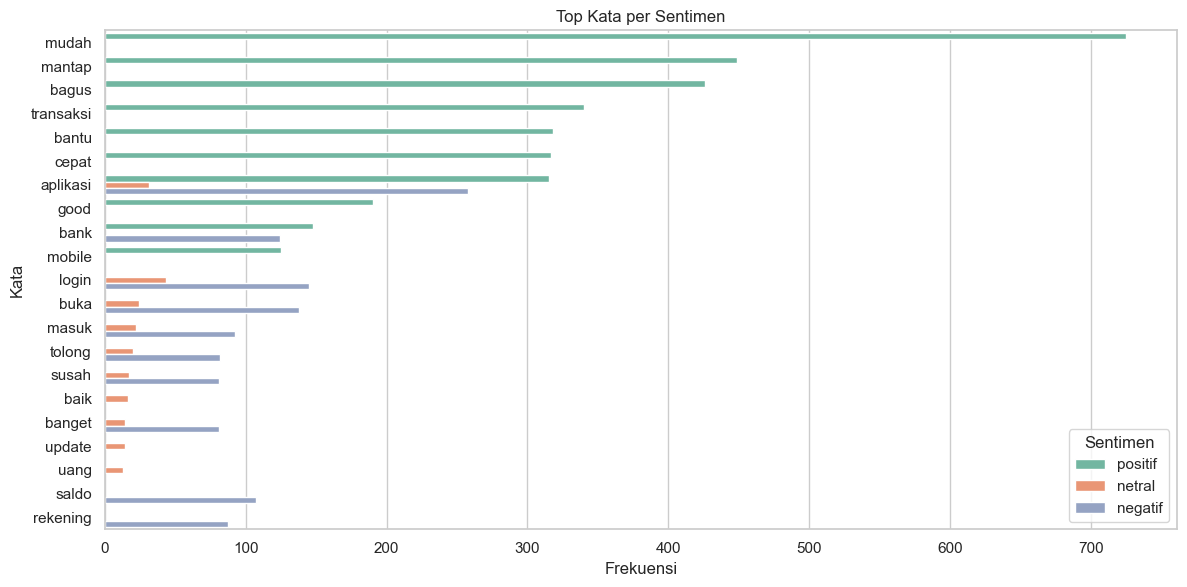

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=sentimen_words_df,
    x="frequency",
    y="word",
    hue="sentimen",
    palette="Set2"
    )
plt.title("Top Kata per Sentimen")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.legend(title="Sentimen")
plt.tight_layout()
plt.show()

### Penjelasan Output
- Grafik ini membandingkan kata dominan antar sentimen dalam satu visual.
- Warna berbeda menunjukkan kelompok sentimen yang berbeda.
- Jika kata pada sentimen negatif sangat spesifik (misalnya terkait kendala), itu bisa jadi prioritas perbaikan produk.

## Kesimpulan Singkat

- Tahapan BoW utama sudah dilakukan sesuai format contoh dosen.
- Matrix BoW siap dipakai untuk modeling lanjutan (Naive Bayes, Logistic Regression, atau SVM).
- Analisis tambahan membantu memahami kata dominan global dan per kategori sentimen.